# W1D4 extra — Support Vector Machines — Lab

**Week 1 · Day 4 · Foundations** · Extra lab · optional

Logistic regression draws one straight line and lets every point vote on where it goes. A support
vector machine asks a narrower question: *which line leaves the widest empty corridor between the two
classes?* Only the points touching that corridor — the support vectors — get a say. Everything else is
ignored, and that is not a shortcut; it is the idea.

Then comes the part worth the hour. A trick called the kernel lets the same machine draw a boundary
that **curves**, without you inventing a single new column. Today you watch a straight line fail on two
interleaving half-moons, switch one argument, and watch it succeed.

**Time budget:** ~55 minutes. This lab is optional extra practice for Day 4.

<div dir="rtl" align="right">

# الأسبوع ١ اليوم ٤ إضافي — آلات المتّجهات الداعمة

**الأسبوع ١ · اليوم ٤ · الأساسيات** · معمل إضافي · اختياري

الانحدار اللوجستي يرسم خطًّا مستقيمًا واحدًا ويترك كل نقطة تُدلي بصوتها في موضعه. أما آلة المتّجهات
الداعمة فتسأل سؤالًا أضيق: **أيّ خطّ يترك أوسع ممرّ فارغ بين الفئتين؟** ولا يُسمع إلا للنقاط الملامسة
لذلك الممرّ — وهي المتّجهات الداعمة. وما عداها يُهمَل، وليس ذلك اختصارًا بل هو الفكرة نفسها.

ثم يأتي الجزء الذي يستحقّ الساعة. فحيلة تُسمّى النواة تجعل الآلة نفسها ترسم حدًّا **منحنيًا** دون أن
تخترع عمودًا جديدًا واحدًا. اليوم ترى خطًّا مستقيمًا يفشل على هلالين متداخلين، ثم تُبدّل وسيطًا واحدًا
وتراه ينجح.

**الزمن المتوقّع:** نحو ٥٥ دقيقة. هذا المعمل إضافي اختياري لليوم الرابع.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Say what a support vector is, and show that removing the other points would change nothing.
- Fit a linear and an RBF support vector machine and explain the difference in one sentence.
- Read `C` as a dial between a wide margin with mistakes inside it and a narrow margin with none.
- Show, with one number, why a support vector machine must never be given unscaled columns.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- أن تقول ما المتّجه الداعم، وأن تُظهر أن حذف بقية النقاط لن يغيّر شيئًا.
- أن تُدرّب آلة متّجهات داعمة خطّية وأخرى بنواة RBF وتشرح الفرق في جملة واحدة.
- أن تقرأ `C` بوصفه مفتاحًا بين ممرّ واسع بداخله أخطاء وممرّ ضيّق بلا خطأ.
- أن تُظهر برقم واحد لماذا يجب ألّا تُعطى آلة المتّجهات الداعمة أعمدة غير مُوحَّدة المقياس.

</div>

## About the data

**Dataset:** `moons_toy` — two interleaving half-moons · CC0, generated with seed 42 · 500 rows

Two columns, `x1` and `x2`, and a label that is 0 or 1 — 250 of each. It is a toy, deliberately: two
columns is the largest number you can draw, and a boundary you cannot see is a boundary you cannot
argue about.

**Watch out:** the moons were generated with noise 0.2, so the two classes genuinely overlap a little.
Perfect accuracy is not available here, and a model that reaches it has memorised the training set.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `moons_toy` — هلالان متداخلان · رخصة CC0 بالبذرة ٤٢ · ٥٠٠ صفّ

عمودان، `x1` و`x2`، وتسمية قيمتها صفر أو واحد — ٢٥٠ لكل فئة. وهي بيانات تجريبية عن قصد: فالعمودان هما
أكبر عدد يمكنك رسمه، والحدّ الذي لا تستطيع رؤيته حدٌّ لا تستطيع مناقشته.

**انتبه:** وُلِّد الهلالان بضوضاء مقدارها ٠٫٢، فالفئتان متداخلتان فعلًا بعض الشيء. والدقة الكاملة غير
متاحة هنا، والنموذج الذي يبلغها يكون قد حفظ بيانات التدريب.

</div>

## Setup

Run the cell below first. It loads the moons, splits them 70/30 with the class balance preserved, and
defines `plot_boundary(model, ax, X, y, title)` — it shades what the model predicts across the whole
plane and scatters the points on top. The mesh is plumbing, not the lesson, so it is written for you.

<div dir="rtl" align="right">

## التهيئة

شغّل الخلية أدناه أولًا. تُحمّل الهلالين، وتقسمهما ٧٠ / ٣٠ مع الحفاظ على توازن الفئتين، وتُعرّف
`plot_boundary(model, ax, X, y, title)` التي تُظلّل ما يتنبّأ به النموذج عبر المستوى كلّه وتنثر النقاط
فوقه. وبناء الشبكة سباكة لا درس، ولذلك كُتب لك جاهزًا.

</div>

In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    # A clone that never ran `uv pip install -e shared/` still has the package on disk —
    # use it before reaching for the network. Colab (no clone) falls through to pip.
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions
from aiep.data import get_dataset, describe_dataset
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("scikit-learn", "matplotlib")
seed_everything(42)

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

from aiep.viz import use_course_style
use_course_style()

DATA = get_dataset("moons_toy")
_df = pd.read_parquet(DATA)

FEATURES = ["x1", "x2"]
X = _df[FEATURES].to_numpy(dtype=float)
y = _df["label"].to_numpy(dtype=int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42)


def plot_boundary(model, ax, X, y, title):
    """Shade the model's prediction over the plane and scatter the points on top.

    Written for you: the mesh is plumbing, not the lesson.
    """
    pad = 0.5
    x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
    y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    zz = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], colors=["tab:blue", "tab:red"], alpha=0.25)
    for label, colour in [(0, "tab:blue"), (1, "tab:red")]:
        ax.scatter(X[y == label, 0], X[y == label, 1], s=14, color=colour, label=f"class {label}")
    ax.set_title(title)
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")


print(describe_dataset("moons_toy"))
print(f"\ntrain {X_train.shape[0]} rows | test {X_test.shape[0]} rows | "
      f"class balance {y.mean():.2f}")
print("\n", versions())

📁 moons_toy: using cached file at C:\Users\ACER\AIEP_Olo_student\shared\data_cache\moons_toy.parquet
moons_toy  (500 rows, 0.01 MB)
  Source:  Built for this course
  Licence: CC0 (generated with sklearn.datasets.make_moons, seed 42)
  Target:  label

  EN: Two interleaving half-moons — not linearly separable, small enough to train a from-scratch NumPy network on in seconds, and 2-D so the decision boundary can be drawn. Used across W3D2-D5 so students compare like with like all week.
  AR: هلالان متداخلان — غير قابلين للفصل خطيًا، وصغيران بما يكفي لتدريب شبكة مكتوبة من الصفر بـ NumPy في ثوانٍ، وثنائيا البعد فيمكن رسم حدّ القرار. يُستخدمان من اليوم الثاني إلى الخامس في الأسبوع الثالث ليقارن الطلاب المتشابه بالمتشابه طوال الأسبوع.

  ⚠️  Watch out: Noise is set to 0.2, so perfect accuracy is impossible — a student chasing 100% is overfitting.
  ⚠️  انتبه: الضوضاء مضبوطة على ٠٫٢، فالدقة الكاملة مستحيلة؛ ومن يطارد ١٠٠٪ فهو يقع في فرط المطابقة.

train 350 rows | test 150 rows | class balan

## Section 1 — Warm-up: one straight line, and the points that choose it  (≈15 min)

A linear support vector machine looks for the widest empty corridor it can fit between the two classes.
The points that end up touching the corridor are the **support vectors**; every other point could be
deleted and the boundary would not move by a millimetre.

<div dir="rtl" align="right">

## القسم الأول — الإحماء: خطّ مستقيم واحد والنقاط التي تختاره (نحو ١٥ دقيقة)

آلة المتّجهات الداعمة الخطّية تبحث عن أوسع ممرّ فارغ يمكن أن تُدخله بين الفئتين. والنقاط التي تلامس
الممرّ في النهاية هي **المتّجهات الداعمة**؛ وكل نقطة أخرى يمكن حذفها دون أن يتزحزح الحدّ مليمترًا
واحدًا.

</div>

### Task 1.1 — fit a straight line and watch it fail

Fit `SVC(kernel="linear", C=1.0)` on the training half, call it `linear_svm`, and plot its boundary over
the test points with `plot_boundary`.

Report two numbers: the test accuracy, and how many of the 350 training points ended up as support
vectors (`len(model.support_)`).

<div dir="rtl" align="right">

### المهمة ١٫١ — درّب خطًّا مستقيمًا وراقب فشله

درّب `SVC(kernel="linear", C=1.0)` على نصف التدريب وسمِّه `linear_svm`، وارسم حدّه فوق نقاط الاختبار
باستخدام `plot_boundary`.

واذكر رقمين: دقّة الاختبار، وكم نقطة من نقاط التدريب الـ٣٥٠ صارت متّجهات داعمة
(‎`len(model.support_)`‎).

</div>

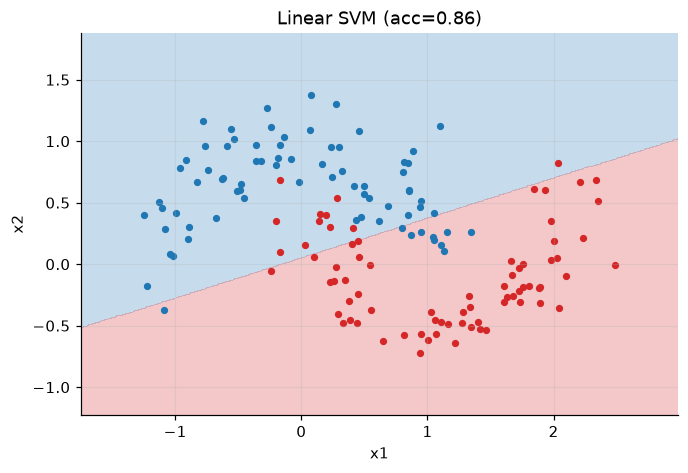

linear SVM test accuracy : 0.8600
support vectors          : 111 of 350 training points


In [2]:
# ────────────────────────────────────────────────────────────────────
# 1) SVC is already imported in the setup cell. Pass kernel="linear" and C=1.0, then .fit().
# 2) Name it `linear_svm` — the comparison, the artefact and the sanity check all read it.
# 3) Make one axes with plt.subplots(), then call plot_boundary(model, ax, X_test, y_test, title).
# 4) A fitted SVC carries .support_ — the row positions of its support vectors. len() them.
# Search: "sklearn SVC kernel linear support_ attribute"
# https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
#
# ١) الصنف SVC مستورد أصلًا في خلية التهيئة. مرّر kernel="linear" وC=1.0 ثم ‎.fit()‎.
# ٢) سمِّه `linear_svm` — فالمقارنة وخلية الحفظ وفحص النتائج كلّها تقرؤه.
# ٣) أنشئ محاور واحدة بـplt.subplots() ثم استدعِ plot_boundary(model, ax, X_test, y_test, title).
# ٤) الـSVC المُدرَّب يحمل ‎.support_‎ وهي مواضع صفوف متّجهاته الداعمة. خذ طولها بـlen().
# ابحث عن: "sklearn SVC kernel linear support_ attribute"
# ────────────────────────────────────────────────────────────────────

# TODO: Fit a linear SVC called `linear_svm`, plot its boundary over the test points, and report its accuracy and its number of support vectors.
# مهمة: درّب SVC خطّيًا باسم `linear_svm`، وارسم حدّه فوق نقاط الاختبار، واذكر دقّته وعدد متّجهاته الداعمة.

linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_train, y_train)

linear_accuracy = linear_svm.score(X_test, y_test)

fig, ax = plt.subplots()
plot_boundary(linear_svm, ax, X_test, y_test,
              title=f"Linear SVM (acc={linear_accuracy:.2f})")
plt.show()

print(f"linear SVM test accuracy : {linear_accuracy:.4f}")
print(f"support vectors          : {len(linear_svm.support_)} "
      f"of {len(X_train)} training points")

Eighty-six percent, and you can see exactly where the missing fourteen went: the two horns of the
moons reach around each other, and no straight line can be on the correct side of both.

The support-vector count is the other half of the story. Roughly a third of the training points are
holding this line in place. The other two thirds are decoration — delete them, refit, and you get the
same line back. That is what makes this model different from logistic regression, where every point
nudges the answer a little.

<div dir="rtl" align="right">

ستّ وثمانون بالمئة، وتستطيع أن ترى أين ذهبت الأربع عشرة الناقصة: فقرنا الهلالين يلتفّ كلٌّ منهما حول
الآخر، ولا يوجد خطّ مستقيم يقع في الجهة الصحيحة منهما معًا.

وعدد المتّجهات الداعمة هو النصف الآخر من القصّة. فنحو ثلث نقاط التدريب هي التي تُمسك هذا الخطّ في
مكانه. والثلثان الباقيان زينة — احذفهما وأعِد التدريب فسيعود الخطّ نفسه. وهذا ما يجعل هذا النموذج
مختلفًا عن الانحدار اللوجستي الذي تدفع فيه كل نقطة الإجابة قليلًا.

</div>

## Section 2 — Core: curved boundaries, and the two dials  (≈30 min)

This is the lab. The kernel changes the *shape* the boundary is allowed to take; `C` changes how much
the model is willing to pay to avoid mistakes. Then one number shows why neither matters if you forget
to scale.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: الحدود المنحنية والمفتاحان (نحو ٣٠ دقيقة)

هذا هو صلب المعمل. النواة تغيّر **شكل** الحدّ المسموح به، و`C` يغيّر كم يقبل النموذج أن يدفع لتجنّب
الأخطاء. ثم يُظهر رقم واحد لماذا لا قيمة لأيٍّ منهما إذا نسيت توحيد المقياس.

</div>

### Task 2.1 — change one argument

Fit exactly the same model with `kernel="rbf"` instead of `"linear"`, call it `rbf_svm`, plot it beside
the linear one, and print both accuracies.

RBF stands for radial basis function. It measures how close two points are to each other rather than
which side of a line they sit on, which is why the boundary it draws can bend.

<div dir="rtl" align="right">

### المهمة ٢٫١ — غيّر وسيطًا واحدًا

درّب النموذج نفسه تمامًا لكن بـ`kernel="rbf"` بدل `"linear"`، وسمِّه `rbf_svm`، وارسمه بجوار الخطّي،
واطبع الدقّتين.

واختصار RBF هو «دالة الأساس الشعاعي». وهي تقيس مدى قرب نقطتين إحداهما من الأخرى بدل أي جهة من الخطّ
تقعان، ولهذا يستطيع الحدّ الذي ترسمه أن ينحني.

</div>

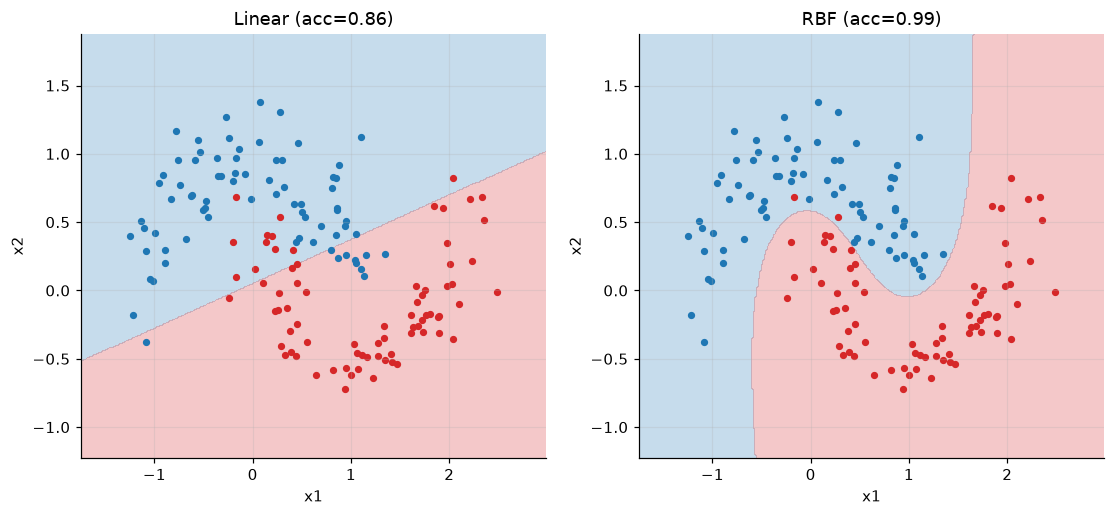

linear : 0.8600  (111 support vectors)
rbf    : 0.9867  (72 support vectors)


In [3]:
# ────────────────────────────────────────────────────────────────────
# 1) Same call as Task 1.1 with kernel="rbf". Nothing else changes. Call it `rbf_svm`.
# 2) plt.subplots(1, 2, figsize=(12, 5)) gives you two axes side by side, as `axes`.
# 3) Call plot_boundary once per axes, with a title naming the kernel and its accuracy.
# 4) Store the test accuracy as `rbf_accuracy` — the sanity check compares it with the linear one.
# Search: "matplotlib subplots two axes side by side"
#
# ١) الاستدعاء نفسه في المهمة ١٫١ مع kernel="rbf". ولا يتغيّر شيء آخر. وسمِّه `rbf_svm`.
# ٢) السطر plt.subplots(1, 2, figsize=(12, 5)) يعطيك محورين متجاورين باسم `axes`.
# ٣) استدعِ plot_boundary مرة لكل محاور، بعنوان يذكر النواة ودقّتها.
# ٤) خزّن دقّة الاختبار باسم `rbf_accuracy` — فالفحص يقارنها بدقّة الخطّي.
# ابحث عن: "matplotlib subplots two axes side by side"
# ────────────────────────────────────────────────────────────────────

# TODO: Fit an RBF SVC called `rbf_svm`, plot it next to the linear one, and compare the two accuracies.
# مهمة: درّب SVC بنواة RBF باسم `rbf_svm`، وارسمه بجوار الخطّي، وقارن الدقّتين.

rbf_svm = SVC(kernel="rbf", C=1.0)
rbf_svm.fit(X_train, y_train)
rbf_accuracy = rbf_svm.score(X_test, y_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plot_boundary(linear_svm, axes[0], X_test, y_test,
              title=f"Linear (acc={linear_accuracy:.2f})")
plot_boundary(rbf_svm, axes[1], X_test, y_test,
              title=f"RBF (acc={rbf_accuracy:.2f})")
plt.show()

print(f"linear : {linear_accuracy:.4f}  ({len(linear_svm.support_)} support vectors)")
print(f"rbf    : {rbf_accuracy:.4f}  ({len(rbf_svm.support_)} support vectors)")

One argument, twelve points of accuracy, and a boundary that follows the shape of the data instead of
cutting across it. It also needs **fewer** support vectors than the straight line did, which is the
clearest sign that the problem was never hard — the model was just the wrong shape for it.

The honest caveat: you could have got something similar by inventing new columns by hand — squares,
products, distances — and feeding them to a linear model. The kernel's contribution is that you did not
have to, and did not have to guess which ones.

<div dir="rtl" align="right">

وسيط واحد، واثنتا عشرة نقطة دقّة، وحدٌّ يتبع شكل البيانات بدل أن يقطعها. بل إنه يحتاج متّجهات داعمة
**أقلّ** ممّا احتاجه الخطّ المستقيم، وهذه أوضح علامة على أن المسألة لم تكن صعبة قطّ — بل كان النموذج
بالشكل الخطأ لها.

والتحفّظ الصادق: كان بإمكانك بلوغ شيء مشابه باختراع أعمدة جديدة بيدك — مربّعات وحواصل ضرب ومسافات —
وإطعامها لنموذج خطّي. وإسهام النواة أنك لم تُضطرّ إلى ذلك، ولم تُضطرّ إلى تخمين أيّ الأعمدة.

</div>

### Task 2.2 — the `C` dial

`C` is the price the model pays for each training point it gets wrong. Small `C` buys a wide corridor
and tolerates mistakes inside it; large `C` refuses mistakes and squeezes the corridor until it fits.

Fit an RBF model at each `C` in `C_VALUES` and draw the four boundaries in one row. Print the training
accuracy, the test accuracy and the support-vector count for each.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — مفتاح `C`

القيمة `C` هي الثمن الذي يدفعه النموذج عن كل نقطة تدريب يُخطئها. فـ`C` الصغيرة تشتري ممرًّا واسعًا
وتتسامح مع الأخطاء داخله، و`C` الكبيرة ترفض الأخطاء وتضغط الممرّ حتى يتّسع لها.

درّب نموذج RBF عند كل قيمة في `C_VALUES` وارسم الحدود الأربعة في صفّ واحد. واطبع دقّة التدريب ودقّة
الاختبار وعدد المتّجهات الداعمة لكل قيمة.

</div>

    C  train_accuracy  test_accuracy  support_vectors
  0.1          0.9257         0.9267              156
  1.0          0.9714         0.9867               72
 10.0          0.9829         0.9867               34
100.0          0.9857         0.9867               24


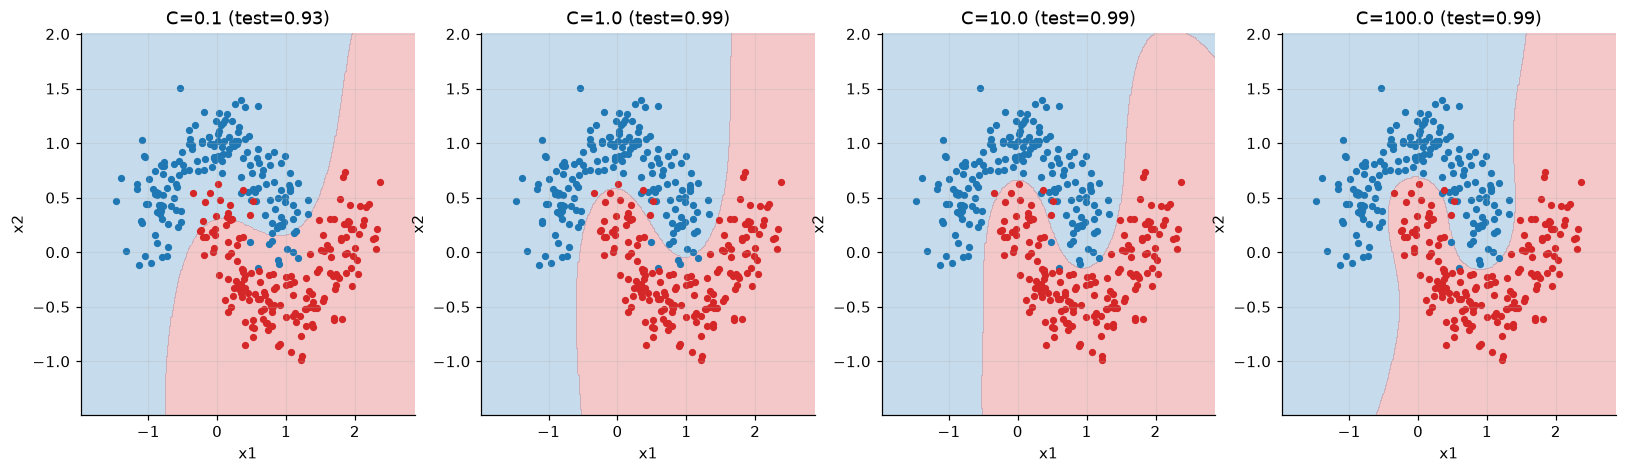

In [4]:
# ────────────────────────────────────────────────────────────────────
# 1) plt.subplots(1, 4, figsize=(18, 4.5)) gives you four axes; zip them with C_VALUES.
# 2) Inside the loop: fit SVC(kernel="rbf", C=value), then plot_boundary onto that axes.
# 3) Collect one dict per C — the value, both accuracies, the support-vector count — into
#    `c_rows`, then print it as a DataFrame so the four rows line up.
# 4) Watch the corridor narrow and the support-vector count fall as C grows. That is the point.
# Search: "sklearn SVC C parameter soft margin"
#
# ١) السطر plt.subplots(1, 4, figsize=(18, 4.5)) يعطيك أربعة محاور؛ اجمعها مع C_VALUES بـzip.
# ٢) وداخل الحلقة: درّب SVC(kernel="rbf", C=value) ثم ارسم plot_boundary على تلك المحاور.
# ٣) اجمع قاموسًا لكل قيمة C — القيمة والدقّتان وعدد المتّجهات الداعمة — في
#    `c_rows`، ثم اطبعه كـDataFrame لتصطفّ الصفوف الأربعة.
# ٤) راقب الممرّ وهو يضيق وعدد المتّجهات الداعمة وهو يقلّ كلما كبرت C. هذا هو المقصد.
# ابحث عن: "sklearn SVC C parameter soft margin"
# ────────────────────────────────────────────────────────────────────

C_VALUES = [0.1, 1.0, 10.0, 100.0]
# TODO: Fit one RBF model per C, draw the four boundaries in a row, and collect train accuracy, test accuracy and support-vector count into `c_rows`.
# مهمة: درّب نموذج RBF لكل قيمة C، وارسم الحدود الأربعة في صفّ، واجمع دقّة التدريب ودقّة الاختبار وعدد المتّجهات الداعمة في `c_rows`.

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
c_rows = []

for C, ax in zip(C_VALUES, axes):
    model = SVC(kernel="rbf", C=C)
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    n_sv = len(model.support_)
    
    plot_boundary(model, ax, X_train, y_train, title=f"C={C} (test={test_acc:.2f})")
    
    c_rows.append({
        "C": C,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "support_vectors": n_sv,
    })

c_table = pd.DataFrame(c_rows)
print(c_table.to_string(index=False))

Read the support-vector column top to bottom: 156, then 72, then 34, then 24. That column is the
corridor closing. At `C = 0.1` the model holds a wide margin and lets a pile of training points sit
inside it; at `C = 100` it has squeezed the corridor down to the two dozen points it cannot avoid.

Now read the two accuracy columns beside it. Training accuracy climbs the whole way. Test accuracy
stops improving after `C = 1`. Everything bought above that was bought on the training set only, which
is the same lesson the tree taught with `max_depth` — a different dial, the same failure.

<div dir="rtl" align="right">

اقرأ عمود المتّجهات الداعمة من أعلى إلى أسفل: ١٥٦ ثم ٧٢ ثم ٣٤ ثم ٢٤. هذا العمود هو الممرّ وهو ينغلق.
فعند `C = 0.1` يُبقي النموذج هامشًا واسعًا ويترك كومة من نقاط التدريب داخله؛ وعند `C = 100` يكون قد ضغط
الممرّ حتى العشرين نقطة وبضع نقاط التي لا يستطيع تجنّبها.

ثم اقرأ عمودَي الدقّة بجواره. دقّة التدريب تصعد طوال الطريق، ودقّة الاختبار تتوقّف عن التحسّن بعد
`C = 1`. وكل ما اشتُري فوق ذلك اشتُري على مجموعة التدريب وحدها، وهو الدرس نفسه الذي علّمته الشجرة
بـ`max_depth` — مفتاح مختلف والفشل نفسه.

</div>

### Task 2.3 — the mistake that costs the most

A support vector machine measures distances. If one column is counted in thousands and another in
single digits, the first column *is* the distance and the second may as well not exist.

`X_wide` below is the same moons with `x2` multiplied by 100 — a stand-in for the everyday case of one
column in currency and another in years. Fit the same RBF model on it twice: once raw, and once inside
a `make_pipeline(StandardScaler(), SVC(kernel="rbf"))`. Print both accuracies.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الخطأ الأغلى ثمنًا

آلة المتّجهات الداعمة تقيس المسافات. فإذا كان عمود يُعدّ بالآلاف وآخر بالآحاد، فإن العمود الأول **هو**
المسافة، والثاني كأنه غير موجود.

والمتغيّر `X_wide` أدناه هو الهلالان نفساهما مع ضرب `x2` في ١٠٠ — نائبًا عن الحالة اليومية: عمود
بالعملة وآخر بالسنوات. درّب نموذج RBF نفسه عليه مرّتين: مرة خامًا، ومرة داخل
`make_pipeline(StandardScaler(), SVC(kernel="rbf"))`. واطبع الدقّتين.

</div>

In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Split X_wide with the SAME test_size, stratify and random_state, or the two runs are
#    not comparable and the number you get means nothing.
# 2) Fit SVC(kernel="rbf") straight on the wide training half. That is `unscaled_accuracy`.
# 3) Then fit make_pipeline(StandardScaler(), SVC(kernel="rbf")) on the same data. The
#    pipeline scales inside the fit, so the test half is never used to compute the mean.
# 4) Name the second one `scaled_accuracy`. The gap is the whole task.
# Search: "sklearn make_pipeline StandardScaler SVC"
#
# ١) قسّم X_wide بالقيم نفسها لـtest_size وstratify وrandom_state، وإلا فالتشغيلان غير
#    قابلين للمقارنة والرقم الذي تحصل عليه لا يعني شيئًا.
# ٢) درّب SVC(kernel="rbf") مباشرة على نصف التدريب الموسّع. وهذه هي `unscaled_accuracy`.
# ٣) ثم درّب make_pipeline(StandardScaler(), SVC(kernel="rbf")) على البيانات نفسها. فالأنبوب
#    يوحّد المقياس داخل التدريب، فلا يُستخدم نصف الاختبار في حساب المتوسّط أبدًا.
# ٤) سمِّ الثانية `scaled_accuracy`. والفجوة بينهما هي المهمة كلّها.
# ابحث عن: "sklearn make_pipeline StandardScaler SVC"
# ────────────────────────────────────────────────────────────────────

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X_wide = X * np.array([1.0, 100.0])       # x2 now runs in the hundreds, x1 does not

X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
    X_wide, y, test_size=0.3, stratify=y, random_state=42)

# بدون توحيد المقياس
unscaled_model = SVC(kernel="rbf")
unscaled_model.fit(X_train_w, y_train_w)
unscaled_accuracy = unscaled_model.score(X_test_w, y_test_w)

# مع توحيد المقياس داخل أنبوب (pipeline)
scaled_model = make_pipeline(StandardScaler(), SVC(kernel="rbf"))
scaled_model.fit(X_train_w, y_train_w)
scaled_accuracy = scaled_model.score(X_test_w, y_test_w)

print(f"unscaled: {unscaled_accuracy:.4f}")
print(f"scaled:   {scaled_accuracy:.4f}")

# TODO: Split X_wide the same way, then fit the RBF model twice — once raw, once behind a StandardScaler — and report both test accuracies.
# مهمة: قسّم X_wide بالطريقة نفسها، ثم درّب نموذج RBF مرّتين — مرة خامًا ومرة خلف StandardScaler — واذكر دقّتَي الاختبار.
print(f"same model, unscaled columns : {unscaled_accuracy:.4f}")
print(f"same model, scaled columns   : {scaled_accuracy:.4f}")
print(f"cost of forgetting to scale  : {scaled_accuracy - unscaled_accuracy:+.4f}")

unscaled: 0.8067
scaled:   0.9867
same model, unscaled columns : 0.8067
same model, scaled columns   : 0.9867
cost of forgetting to scale  : +0.1800


Eighteen points of accuracy, thrown away by one multiplication. No argument changed, no worse model was
chosen, no data was lost — `x2` simply got louder, and the distance the kernel measures stopped hearing
`x1` at all.

This is the reason `StandardScaler` belongs inside a pipeline rather than in a cell of its own: written
this way, the scaler learns its mean and standard deviation from the training half only, every time,
including inside cross-validation. Scale in a separate cell and you will eventually scale before you
split, and quietly let the test set leak into training.

<div dir="rtl" align="right">

ثماني عشرة نقطة دقّة، ضاعت بعملية ضرب واحدة. لم يتغيّر وسيط، ولم يُختَر نموذج أسوأ، ولم تُفقد بيانات —
بل صار `x2` أعلى صوتًا فحسب، فلم تعد المسافة التي تقيسها النواة تسمع `x1` إطلاقًا.

وهذا سبب وضع `StandardScaler` داخل الأنبوب لا في خلية مستقلّة: فبهذه الكتابة يتعلّم المُوحِّد متوسّطه
وانحرافه المعياري من نصف التدريب وحده، في كل مرة، وحتى داخل التحقّق المتقاطع. أما لو وحّدت المقياس في
خلية منفصلة فستوحّده يومًا ما قبل التقسيم، وتترك مجموعة الاختبار تتسرّب إلى التدريب بصمت.

</div>

## Section 3 — Stretch: the other dial  (≈10 min)

Open-ended, and lower expectation of completeness. Finish it at home if the room moves on.

`gamma` controls how far a single training point's influence reaches. Small `gamma` means every point
is felt from far away and the boundary is smooth; large `gamma` means each point is felt only right
next to itself, and the boundary becomes a set of little islands around individual training points.

Fit an RBF model at each `gamma` in `GAMMAS` and print the training and test accuracy for each. One of
the four is the classic picture of overfitting. Name it.

<div dir="rtl" align="right">

## القسم الثالث — إضافي: المفتاح الآخر (نحو ١٠ دقائق)

مفتوح، والتوقّع فيه أقلّ من حيث الاكتمال. أكمله في المنزل إن مضت القاعة.

الوسيط `gamma` يتحكّم في المدى الذي يصل إليه أثر نقطة تدريب واحدة. فالقيمة الصغيرة تعني أن كل نقطة
يُحسّ بها من بعيد ويكون الحدّ ناعمًا؛ والقيمة الكبيرة تعني أن كل نقطة لا يُحسّ بها إلا بجوارها تمامًا،
فيصير الحدّ جزرًا صغيرة حول نقاط تدريب منفردة.

درّب نموذج RBF عند كل قيمة في `GAMMAS` واطبع دقّة التدريب ودقّة الاختبار لكل منها. وواحدة من الأربع هي
الصورة الكلاسيكية لفرط المطابقة. سمِّها.

</div>

 gamma  train_accuracy  test_accuracy     gap
   0.1          0.8657         0.8733 -0.0076
   1.0          0.9714         0.9867 -0.0152
  10.0          0.9829         0.9800  0.0029
 100.0          0.9914         0.9467  0.0448


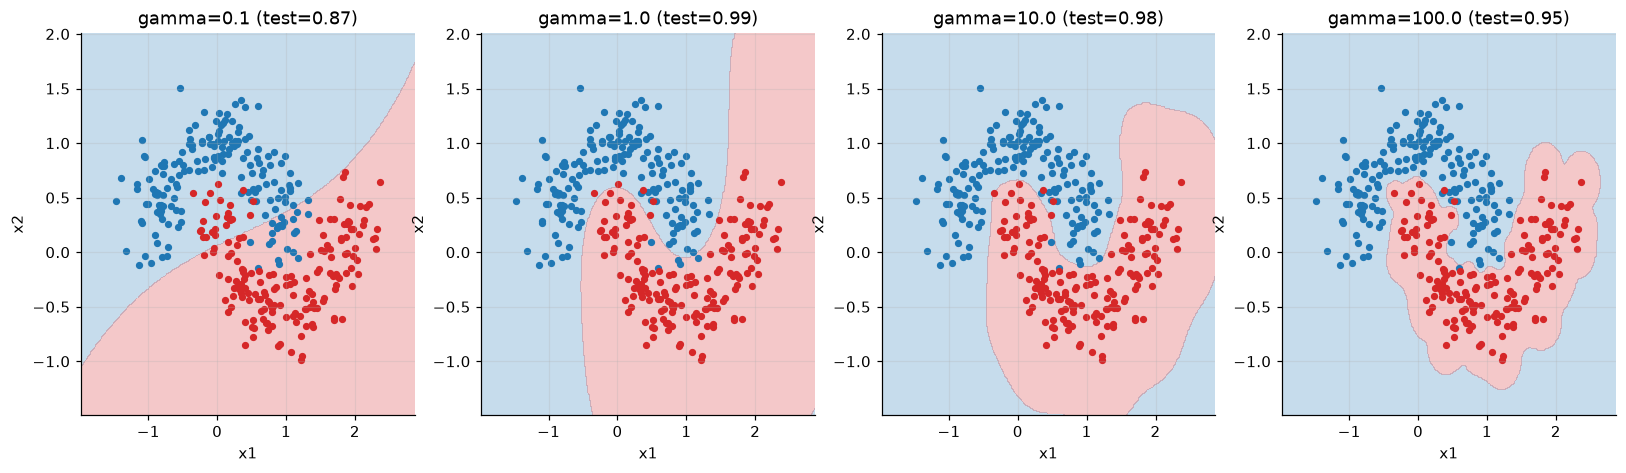

In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) Same loop shape as Task 2.2, with gamma=value instead of C=value.
# 2) Print both accuracies per gamma, and the gap between them — the gap is the signal.
# 3) Overfitting looks like this: training accuracy still rising, test accuracy falling.
# 4) If you want to see it, plot the largest gamma with plot_boundary on the training points.
# Search: "sklearn SVC gamma rbf kernel overfitting"
#
# ١) الحلقة نفسها في المهمة ٢٫٢، مع gamma=value بدل C=value.
# ٢) اطبع الدقّتين لكل gamma والفجوة بينهما — فالفجوة هي الإشارة.
# ٣) فرط المطابقة يبدو هكذا: دقّة التدريب لا تزال تصعد ودقّة الاختبار تهبط.
# ٤) وإن أردت رؤيته فارسم أكبر gamma بـplot_boundary على نقاط التدريب.
# ابحث عن: "sklearn SVC gamma rbf kernel overfitting"
# ────────────────────────────────────────────────────────────────────

GAMMAS = [0.1, 1.0, 10.0, 100.0]

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
gamma_rows = []

for gamma, ax in zip(GAMMAS, axes):
    model = SVC(kernel="rbf", gamma=gamma)
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    gap = train_acc - test_acc
    
    plot_boundary(model, ax, X_train, y_train,
                  title=f"gamma={gamma} (test={test_acc:.2f})")
    
    gamma_rows.append({
        "gamma": gamma,
        "train_accuracy": round(train_acc, 4),
        "test_accuracy": round(test_acc, 4),
        "gap": round(gap, 4),
    })

gamma_table = pd.DataFrame(gamma_rows)
print(gamma_table.to_string(index=False))

# TODO: Fit an RBF model per gamma and print its training accuracy, test accuracy and the gap.
# مهمة: درّب نموذج RBF لكل gamma واطبع دقّة التدريب ودقّة الاختبار والفجوة بينهما.

## Save your artefact

`svm_intro.json` records the linear and RBF accuracies and what forgetting to scale cost you. Keep it
beside `trees_intro.json` from the other extra lab: three model families, one dataset each, and a
written number for every one of them.

<div dir="rtl" align="right">

## احفظ ناتجك

يسجّل الملف `svm_intro.json` دقّة الخطّي ودقّة RBF وما كلّفك نسيان توحيد المقياس. واحتفظ به بجوار
`trees_intro.json` من المعمل الإضافي الآخر: ثلاث عائلات نماذج، ومجموعة بيانات لكل منها، ورقم مكتوب لكل
واحدة.

</div>

In [7]:
metrics = {
    "dataset": "moons_toy",
    "features": FEATURES,
    "n_train": int(len(y_train)),
    "n_test": int(len(y_test)),
    "accuracy_linear": round(linear_accuracy, 4),
    "accuracy_rbf": round(rbf_accuracy, 4),
    "support_vectors_linear": int(len(linear_svm.support_)),
    "support_vectors_rbf": int(len(rbf_svm.support_)),
    "accuracy_unscaled": round(unscaled_accuracy, 4),
    "accuracy_scaled": round(scaled_accuracy, 4),
}

out = ARTEFACT_DIR / "svm_intro.json"
out.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Saved {out}")
print(json.dumps(metrics, indent=2))

Saved c:\Users\ACER\AIEP_Olo_student\week_1_foundations\labs\D4_extra_svm\artefacts\svm_intro.json
{
  "dataset": "moons_toy",
  "features": [
    "x1",
    "x2"
  ],
  "n_train": 350,
  "n_test": 150,
  "accuracy_linear": 0.86,
  "accuracy_rbf": 0.9867,
  "support_vectors_linear": 111,
  "support_vectors_rbf": 72,
  "accuracy_unscaled": 0.8067,
  "accuracy_scaled": 0.9867
}


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخلية أخيرًا. كل فحص يفشل يخبرك بما يجب إصلاحه ولماذا.

</div>

In [8]:
# --- Sanity checks ----------------------------------------------------------------
check(rbf_accuracy > linear_accuracy,
      f"the curved boundary should beat the straight one on two moons: rbf {rbf_accuracy:.4f} vs "
      f"linear {linear_accuracy:.4f} — if not, check you changed the kernel and nothing else",
      f"يجب أن يتفوّق الحدّ المنحني على المستقيم على الهلالين: rbf {rbf_accuracy:.4f} مقابل "
      f"linear {linear_accuracy:.4f} — وإن لم يحدث فتحقّق أنك غيّرت النواة ولا شيء غيرها")

check(0 < len(linear_svm.support_) < len(X_train),
      f"support vectors must be some of the training points, not none and not all: "
      f"{len(linear_svm.support_)} of {len(X_train)}",
      f"يجب أن تكون المتّجهات الداعمة بعض نقاط التدريب لا صفرًا ولا كلّها: "
      f"{len(linear_svm.support_)} من {len(X_train)}")

check(len(c_table) == 4,
      f"the C sweep needs one row per value in C_VALUES (4), got {len(c_table)}",
      f"يحتاج مسح C صفًّا لكل قيمة في C_VALUES (٤)، ولديك {len(c_table)}")

check(c_table["support_vectors"].iloc[0] > c_table["support_vectors"].iloc[-1],
      f"a small C must keep more support vectors than a large one: "
      f"{int(c_table['support_vectors'].iloc[0])} at C={c_table['C'].iloc[0]} vs "
      f"{int(c_table['support_vectors'].iloc[-1])} at C={c_table['C'].iloc[-1]}",
      f"يجب أن تُبقي C الصغيرة متّجهات داعمة أكثر من الكبيرة: "
      f"{int(c_table['support_vectors'].iloc[0])} عند C={c_table['C'].iloc[0]} مقابل "
      f"{int(c_table['support_vectors'].iloc[-1])} عند C={c_table['C'].iloc[-1]}")

check(scaled_accuracy - unscaled_accuracy > 0.05,
      f"scaling should rescue the stretched columns by a wide margin: {scaled_accuracy:.4f} scaled "
      f"vs {unscaled_accuracy:.4f} unscaled — if they match, check you fitted on X_wide, not X",
      f"يجب أن ينقذ توحيد المقياس الأعمدة الممدودة بفارق واسع: {scaled_accuracy:.4f} موحَّدة "
      f"مقابل {unscaled_accuracy:.4f} غير موحَّدة — فإن تساوتا فتحقّق أنك درّبت على X_wide لا X")

check((ARTEFACT_DIR / "svm_intro.json").exists(),
      "svm_intro.json should exist — run the save cell above",
      "يجب أن يوجد الملف svm_intro.json — شغّل خلية الحفظ أعلاه")

report()

──────────────────────────────────────────────────────────────────
  ✓  the curved boundary should beat the straight one on two moons: rbf 0.9867 vs linear 0.8600 — if not, check you changed the kernel and nothing else
  ✓  support vectors must be some of the training points, not none and not all: 111 of 350
  ✓  the C sweep needs one row per value in C_VALUES (4), got 4
  ✓  a small C must keep more support vectors than a large one: 156 at C=0.1 vs 24 at C=100.0
  ✓  scaling should rescue the stretched columns by a wide margin: 0.9867 scaled vs 0.8067 unscaled — if they match, check you fitted on X_wide, not X
  ✓  svm_intro.json should exist — run the save cell above
──────────────────────────────────────────────────────────────────
  ✅ All 6 checks passed. / اجتزت جميع الفحوصات (6).
──────────────────────────────────────────────────────────────────


## What's next

You have now met three shapes of boundary in one day: a straight line, a staircase of boxes, and a
curve. None of them is the best model; each is the best model for a shape of data, and the only way to
know which shape you have is to look at it — which is the whole of Week 2.

<div dir="rtl" align="right">

## ماذا بعد

التقيت اليوم بثلاثة أشكال لحدّ القرار: خطّ مستقيم، وسُلّم من الصناديق، ومنحنى. وليس أيّ منها أفضل
نموذج؛ بل كلٌّ منها أفضل نموذج لشكل معيّن من البيانات، والسبيل الوحيد لمعرفة أيّ شكل لديك هو أن تنظر
إليه — وذلك هو الأسبوع الثاني كلّه.

</div>